In [2]:
!pip install faiss-cpu scikit-learn-intelex sentencepiece -q

In [3]:
import warnings
import torch
import pandas as pd
import numpy as np
import faiss
import joblib
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tqdm import tqdm

warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [4]:
clf = joblib.load('logistic_regression_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

train = pd.read_csv('train_lemmatized.csv').dropna(subset=['message_lemmatized', 'label'])
val = pd.read_csv('val_lemmatized.csv').dropna(subset=['message_lemmatized', 'label'])
test = pd.read_csv('test_lemmatized.csv').dropna(subset=['message_lemmatized', 'label'])


In [5]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

bert_classifier = pipeline(
    "text-classification",
    model="MariaOnyshchuk/prop_xlmroberta",
    device=0 if device == 'cuda' else -1,
    return_all_scores=True
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


In [6]:
documents = train['message_lemmatized'].tolist()
doc_labels = train['label'].tolist()

embeddings = embedding_model.encode(documents, batch_size=64, show_progress_bar=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

Batches:   0%|          | 0/479 [00:00<?, ?it/s]

In [7]:
def batch_retrieve(texts, top_k=3):
    query_embeddings = embedding_model.encode(texts, batch_size=32, show_progress_bar=False)
    distances, indices = index.search(query_embeddings.astype('float32'), top_k)

    batch_retrieved = []
    for i in range(len(texts)):
        retrieved = []
        for idx, dist in zip(indices[i], distances[i]):
            retrieved.append({
                'text': documents[idx],
                'label': doc_labels[idx],
                'distance': float(dist)
            })
        batch_retrieved.append(retrieved)

    return batch_retrieved

def ensemble_classify(texts, bert_weight=0.6, lr_weight=0.4, batch_size=16):
    retrieved_docs_list = batch_retrieve(texts, top_k=3)

    bert_probs_all = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_retrieved = retrieved_docs_list[i:i+batch_size]

        augmented_texts = []
        for text, retrieved in zip(batch_texts, batch_retrieved):
            context = "\n".join([doc['text'][:100] for doc in retrieved[:2]])
            augmented_texts.append(f"{context}\n\n{text}")

        batch_results = bert_classifier(augmented_texts, truncation=True, max_length=512)

        for result in batch_results:
            probs = np.array([score['score'] for score in result])
            bert_probs_all.append(probs)

    bert_probs_all = np.array(bert_probs_all)

    X_test = vectorizer.transform(texts)
    lr_probs = clf.predict_proba(X_test)

    ensemble_probs = bert_weight * bert_probs_all + lr_weight * lr_probs
    predictions = np.argmax(ensemble_probs, axis=1)

    return predictions, ensemble_probs


In [8]:
print("="*70)
print("VALIDATION SET: Finding optimal weights")
print("="*70)

val_texts = val['message_lemmatized'].tolist()
val_labels = val['label'].tolist()

weight_results_val = []
for bert_w in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    lr_w = 1.0 - bert_w
    predictions, _ = ensemble_classify(val_texts, bert_w, lr_w)

    acc = accuracy_score(val_labels, predictions)
    f1 = f1_score(val_labels, predictions, average='macro')

    weight_results_val.append({
        'bert_weight': bert_w,
        'lr_weight': lr_w,
        'accuracy': acc,
        'f1_score': f1
    })
    print(f"BERT: {bert_w:.1f}, LR: {lr_w:.1f} => Acc: {acc:.4f}, F1: {f1:.4f}")

weight_df_val = pd.DataFrame(weight_results_val)
best_weights = weight_df_val.loc[weight_df_val['f1_score'].idxmax()]

print(f"\nBest weights on validation:")
print(f"BERT: {best_weights['bert_weight']:.1f}, LR: {best_weights['lr_weight']:.1f}")
print(f"F1: {best_weights['f1_score']:.4f}, Accuracy: {best_weights['accuracy']:.4f}")


VALIDATION SET: Finding optimal weights


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


BERT: 0.0, LR: 1.0 => Acc: 0.7270, F1: 0.7267
BERT: 0.1, LR: 0.9 => Acc: 0.7290, F1: 0.7280
BERT: 0.2, LR: 0.8 => Acc: 0.7247, F1: 0.7227
BERT: 0.3, LR: 0.7 => Acc: 0.7153, F1: 0.7121
BERT: 0.4, LR: 0.6 => Acc: 0.6969, F1: 0.6921
BERT: 0.5, LR: 0.5 => Acc: 0.6673, F1: 0.6595
BERT: 0.6, LR: 0.4 => Acc: 0.6379, F1: 0.6260
BERT: 0.7, LR: 0.3 => Acc: 0.6175, F1: 0.6019
BERT: 0.8, LR: 0.2 => Acc: 0.5909, F1: 0.5694
BERT: 0.9, LR: 0.1 => Acc: 0.5707, F1: 0.5441
BERT: 1.0, LR: 0.0 => Acc: 0.5519, F1: 0.5198

Best weights on validation:
BERT: 0.1, LR: 0.9
F1: 0.7280, Accuracy: 0.7290


In [ ]:
print("\n" + "="*70)
print("TEST SET: Evaluating all weight combinations")
print("="*70)

test_texts = test['message_lemmatized'].tolist()
test_labels = test['label'].tolist()

weight_results_test = []
for bert_w in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    lr_w = 1.0 - bert_w
    predictions, _ = ensemble_classify(test_texts, bert_w, lr_w)

    acc = accuracy_score(test_labels, predictions)
    f1 = f1_score(test_labels, predictions, average='macro')

    weight_results_test.append({
        'bert_weight': bert_w,
        'lr_weight': lr_w,
        'accuracy': acc,
        'f1_score': f1
    })
    print(f"BERT: {bert_w:.1f}, LR: {lr_w:.1f} => Acc: {acc:.4f}, F1: {f1:.4f}")

weight_df_test = pd.DataFrame(weight_results_test)
weight_df_test.to_csv('weight_comparison_results.csv', index=False)


TEST SET: Evaluating all weight combinations
BERT: 0.0, LR: 1.0 => Acc: 0.7255, F1: 0.7256
BERT: 0.1, LR: 0.9 => Acc: 0.7258, F1: 0.7252
BERT: 0.2, LR: 0.8 => Acc: 0.7214, F1: 0.7201
BERT: 0.3, LR: 0.7 => Acc: 0.7155, F1: 0.7130
BERT: 0.4, LR: 0.6 => Acc: 0.6978, F1: 0.6936
BERT: 0.5, LR: 0.5 => Acc: 0.6654, F1: 0.6581
BERT: 0.6, LR: 0.4 => Acc: 0.6396, F1: 0.6290
BERT: 0.7, LR: 0.3 => Acc: 0.6140, F1: 0.5990
BERT: 0.8, LR: 0.2 => Acc: 0.5922, F1: 0.5728
BERT: 0.9, LR: 0.1 => Acc: 0.5697, F1: 0.5448
BERT: 1.0, LR: 0.0 => Acc: 0.5504, F1: 0.5206


In [11]:
print("\n" + "="*70)
print("FINAL RESULTS with best weights from validation")
print("="*70)

final_predictions, _ = ensemble_classify(
    test_texts,
    best_weights['bert_weight'],
    best_weights['lr_weight']
)

final_acc = accuracy_score(test_labels, final_predictions)
final_f1 = f1_score(test_labels, final_predictions, average='macro')

print(f"\nUsing BERT: {best_weights['bert_weight']:.1f}, LR: {best_weights['lr_weight']:.1f}")
print(f"Test Accuracy: {final_acc:.4f}")
print(f"Test F1 Score: {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, final_predictions))

print("\nClassification Report:")
print(classification_report(test_labels, final_predictions,
                          target_names=['misinformation', 'propaganda', 'opposition']))



FINAL RESULTS with best weights from validation

Using BERT: 0.1, LR: 0.9
Test Accuracy: 0.7258
Test F1 Score: 0.7252

Confusion Matrix:
[[2809  501  166]
 [ 751 2221  424]
 [ 371  589 2385]]

Classification Report:
                precision    recall  f1-score   support

misinformation       0.71      0.81      0.76      3476
    propaganda       0.67      0.65      0.66      3396
    opposition       0.80      0.71      0.75      3345

      accuracy                           0.73     10217
     macro avg       0.73      0.73      0.73     10217
  weighted avg       0.73      0.73      0.73     10217



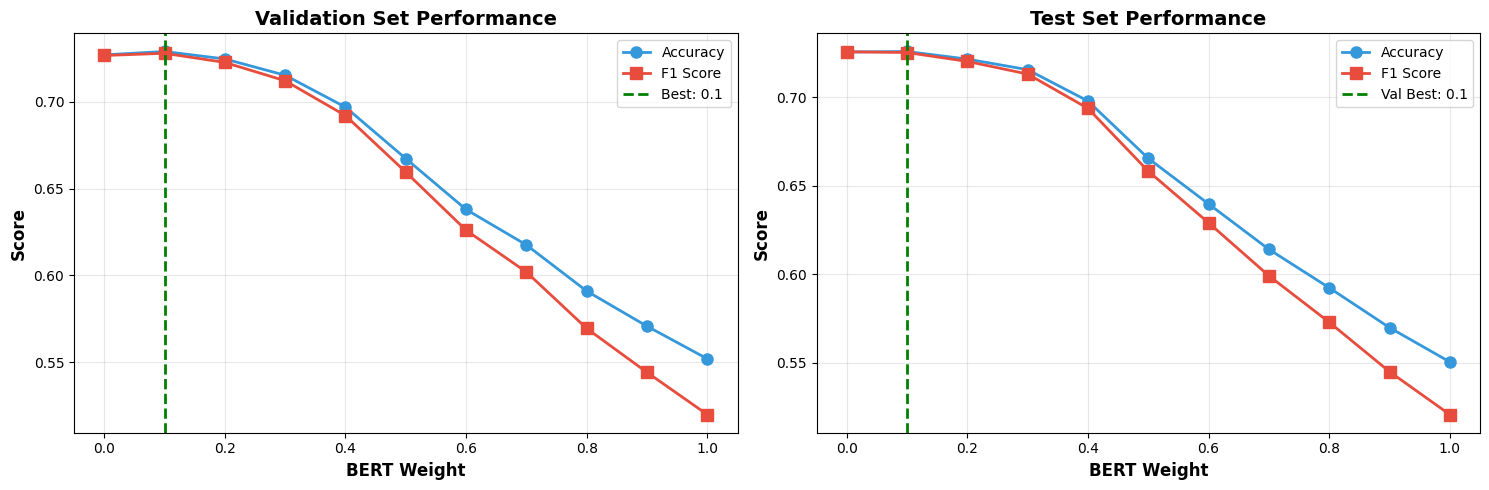

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(weight_df_val['bert_weight'], weight_df_val['accuracy'],
         marker='o', linewidth=2, markersize=8, label='Accuracy', color='#3498db')
ax1.plot(weight_df_val['bert_weight'], weight_df_val['f1_score'],
         marker='s', linewidth=2, markersize=8, label='F1 Score', color='#e74c3c')
ax1.axvline(best_weights['bert_weight'], color='green', linestyle='--',
            label=f'Best: {best_weights["bert_weight"]:.1f}', linewidth=2)
ax1.set_xlabel('BERT Weight', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Validation Set Performance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(weight_df_test['bert_weight'], weight_df_test['accuracy'],
         marker='o', linewidth=2, markersize=8, label='Accuracy', color='#3498db')
ax2.plot(weight_df_test['bert_weight'], weight_df_test['f1_score'],
         marker='s', linewidth=2, markersize=8, label='F1 Score', color='#e74c3c')
ax2.axvline(best_weights['bert_weight'], color='green', linestyle='--',
            label=f'Val Best: {best_weights["bert_weight"]:.1f}', linewidth=2)
ax2.set_xlabel('BERT Weight', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Test Set Performance', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weight_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
